# Casey coarse types vs. original hierarchy leaves

This notebook reads the joined CSV for your v1718 neurons with `axon_partially_extended` or `axon_fully_extended`. It compares Casey coarse types with the original v1718 `cell_classification` labels used as leaves in the project hierarchy. Thalamocortical cells are excluded.

Set `MIN_COARSE_CONFIDENCE` below to filter cells before constructing the matrix. Casey `L2`, `L3`, `L4`, and `L5` are displayed as `L2IT`, `L3IT`, `L4IT`, and `L5IT`; this rename does not assume the classifications agree.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from IPython.display import display


def find_project_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "data/v1718_extended_axon_neurons_casey_comparison.csv").exists():
            return candidate
    raise FileNotFoundError("Run from gnn_classifier or a subdirectory")


ROOT = find_project_root()
CSV = ROOT / "data/v1718_extended_axon_neurons_casey_comparison.csv"
# Set to a number from 0.0 to 1.0, e.g. 0.5. None includes every labeled cell.
MIN_COARSE_CONFIDENCE = None
# Optional second filter on Casey fine confidence.
MIN_FINE_CONFIDENCE = None


## Load and filter cells

The CSV has one row per eligible v1718 neuron. It includes both Casey confidence scores, the original classification, and whether the match used a root ID or nucleus ID. Missing Casey scores remain blank in the CSV.

In [2]:
data = pd.read_csv(CSV, dtype={
    "root_id": "string", "casey_root_id": "string", "casey_cell_id": "string",
})
assert data.root_id.is_unique
for column in ("casey_coarse_confidence", "casey_fine_confidence"):
    data[column] = pd.to_numeric(data[column], errors="raise")
    assert data[column].dropna().between(0, 1).all()

comparison = data.loc[
    (data.cell_classification != "thalamocortical")
    & data.casey_coarse.notna()
    & data.casey_coarse_confidence.notna()
].copy()
if MIN_COARSE_CONFIDENCE is not None:
    assert 0 <= MIN_COARSE_CONFIDENCE <= 1
    comparison = comparison.loc[comparison.casey_coarse_confidence >= MIN_COARSE_CONFIDENCE]
if MIN_FINE_CONFIDENCE is not None:
    assert 0 <= MIN_FINE_CONFIDENCE <= 1
    comparison = comparison.loc[comparison.casey_fine_confidence >= MIN_FINE_CONFIDENCE]

comparison["casey_coarse_display"] = comparison.casey_coarse.replace({
    "L2": "L2IT", "L3": "L3IT", "L4": "L4IT", "L5": "L5IT",
})
print(f"Eligible v1718 neurons in CSV: {len(data):,}")
print(f"Thalamocortical cells excluded: {(data.cell_classification == 'thalamocortical').sum():,}")
print(f"With Casey coarse type before threshold: {((data.cell_classification != 'thalamocortical') & data.casey_coarse.notna()).sum():,}")
print(f"Cells after confidence filter: {len(comparison):,}")


Eligible v1718 neurons in CSV: 2,103
Thalamocortical cells excluded: 30
With Casey coarse type before threshold: 2,068
Cells after confidence filter: 2,068


## Count matrix

Rows are Casey coarse types; columns are the original hierarchy's finest labels. This is a cross-classification table, so its diagonal is not an accuracy measure.

In [3]:
preferred_rows = ["L2IT", "L3IT", "L4IT", "L5IT", "L5ET", "L5NP", "L6CT", "L6IT", "L6b", "BasketFam", "BipFam", "ChC", "MartFam", "NglFam"]
preferred_cols = ["L2IT", "L3IT", "L4IT", "L5IT", "L5ET", "L5NP", "L6IT", "L6CT", "MC", "NMC", "DTC", "PV", "ChC", "ITC", "ITCperi", "NGC", "AltBasket", "AltDTC", "L1"]
raw = pd.crosstab(comparison.casey_coarse_display, comparison.cell_classification)
rows = [x for x in preferred_rows if x in raw.index] + sorted(set(raw.index) - set(preferred_rows))
cols = [x for x in preferred_cols if x in raw.columns] + sorted(set(raw.columns) - set(preferred_cols))
counts = raw.reindex(index=rows, columns=cols, fill_value=0)
assert counts.to_numpy().sum() == len(comparison)
display(counts)


cell_classification,L2IT,L3IT,L4IT,L5IT,L5ET,L5NP,L6IT,L6CT,MC,NMC,DTC,PV,ChC,ITC,ITCperi,NGC,AltBasket,AltDTC,L1
casey_coarse_display,,,,,,,,,,,,,,,,,,,
L2IT,222,10,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
L3IT,63,185,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
L4IT,0,32,516,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
L5IT,0,0,8,113,0,0,4,2,0,0,0,0,0,0,0,0,0,0,0
L5ET,0,0,0,1,52,0,0,0,0,0,0,0,0,0,0,0,0,0,0
L5NP,0,0,0,0,0,10,0,0,0,0,0,0,0,0,0,0,0,0,0
L6CT,0,0,0,0,0,0,2,232,0,0,0,0,0,0,0,0,0,0,0
L6IT,0,0,3,3,0,0,133,11,0,0,0,0,0,0,0,0,0,0,0
L6b,0,0,0,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0,0


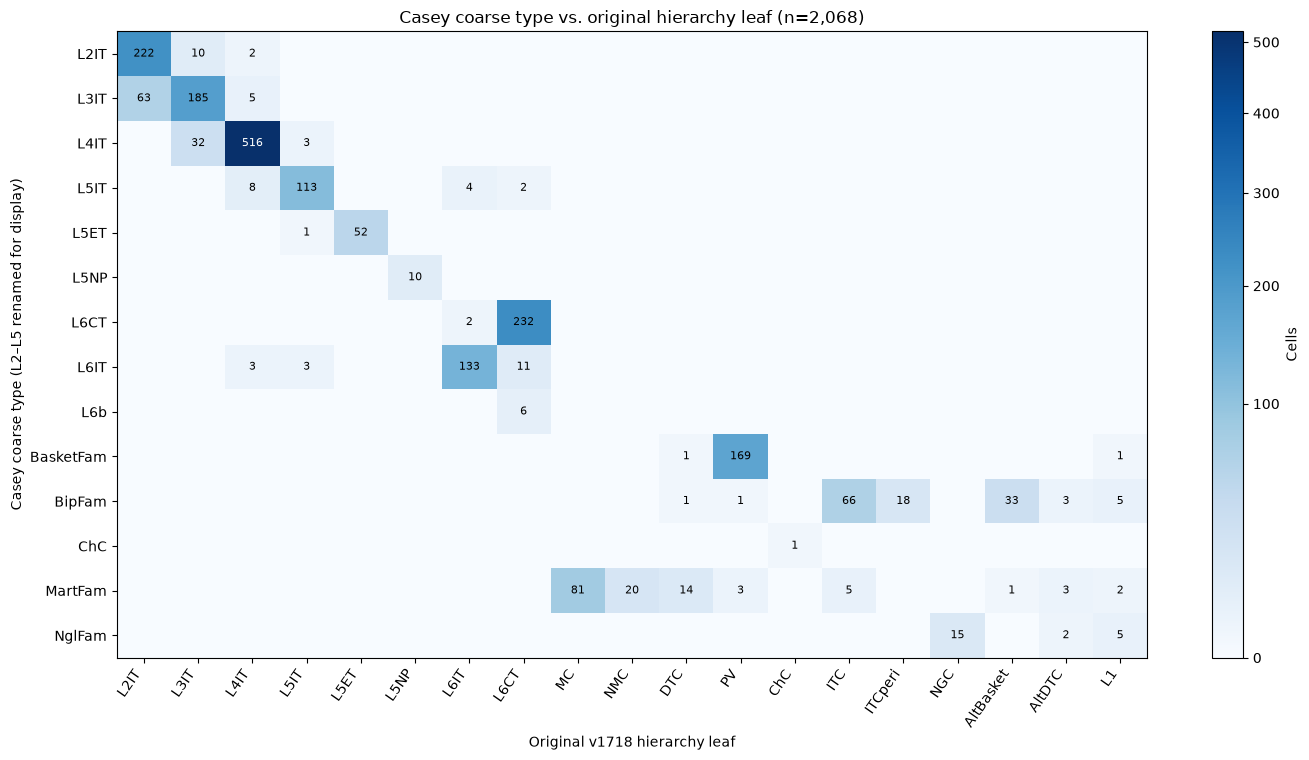

In [4]:
if counts.empty:
    print("No cells pass the selected confidence threshold.")
else:
    fig, ax = plt.subplots(figsize=(max(12, 0.75 * len(counts.columns)), max(7, 0.55 * len(counts))))
    values = counts.to_numpy()
    image = ax.imshow(values, cmap="Blues", aspect="auto", norm=PowerNorm(gamma=0.55, vmin=0, vmax=max(1, values.max())))
    ax.set_xticks(np.arange(len(counts.columns)), counts.columns, rotation=55, ha="right")
    ax.set_yticks(np.arange(len(counts.index)), counts.index)
    ax.set_xlabel("Original v1718 hierarchy leaf")
    ax.set_ylabel("Casey coarse type (L2–L5 renamed for display)")
    ax.set_title(f"Casey coarse type vs. original hierarchy leaf (n={values.sum():,})")
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            if values[i, j]:
                ax.text(j, i, str(values[i, j]), ha="center", va="center", fontsize=8,
                        color="white" if values[i, j] > 0.45 * values.max() else "black")
    fig.colorbar(image, ax=ax, label="Cells")
    fig.tight_layout()
    plt.show()


## Optional row percentages

These show the original-label mix within each Casey coarse type at the selected threshold.

In [5]:
row_percent = counts.div(counts.sum(axis=1), axis=0).mul(100).fillna(0).round(1)
display(row_percent)


cell_classification,L2IT,L3IT,L4IT,L5IT,L5ET,L5NP,L6IT,L6CT,MC,NMC,DTC,PV,ChC,ITC,ITCperi,NGC,AltBasket,AltDTC,L1
casey_coarse_display,,,,,,,,,,,,,,,,,,,
L2IT,94.9,4.3,0.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
L3IT,24.9,73.1,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
L4IT,0.0,5.8,93.6,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
L5IT,0.0,0.0,6.3,89.0,0.0,0.0,3.1,1.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
L5ET,0.0,0.0,0.0,1.9,98.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
L5NP,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
L6CT,0.0,0.0,0.0,0.0,0.0,0.0,0.9,99.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
L6IT,0.0,0.0,2.0,2.0,0.0,0.0,88.7,7.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
L6b,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
